## Evaluación de Modelos

# 1. Predicción de `gasto_mensual`
En esta sección evaluaremos el rendimiento de los modelos entrenados para predecir el gasto mensual de los clientes. Utilizaremos el Error Absoluto Medio (MAE), el RMSE , y el R².

In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from pathlib import Path
import sys

# configura el path al directorio src
project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from model_evaluation import comparar_modelos_regresion
from model_evaluation import comparar_modelos_clasificacion

# define rutas relativas al proyecto
base_dir = project_root if "project_root" in globals() else Path.cwd().resolve()
ruta_modelos = base_dir / "models"
ruta_datos = base_dir / "data" / "processed"

In [2]:
# carga los conjuntos de prueba
X_test = joblib.load(ruta_datos / "X_test_reg.joblib")
y_test = joblib.load(ruta_datos / "y_test_reg.joblib")

# carga los modelos entrenados
pipeline_modelo_lr = joblib.load(ruta_modelos / "pipeline_modelo_lr_reg.joblib")
pipeline_modelo_dtr = joblib.load(ruta_modelos / "pipeline_modelo_dtr_reg.joblib")

# prepara el diccionario para la evaluación 
modelos_entrenados = {
    "Regresión Lineal": pipeline_modelo_lr,
    "Árbol de Decisión": pipeline_modelo_dtr
}

print(f"Datos cargados. X_test shape: {X_test.shape}. Modelos listos para evaluar.")

Datos cargados. X_test shape: (3800, 10). Modelos listos para evaluar.


## Comparación de Métricas de Rendimiento
Utilizamos nuestra función personalizada para evaluar los modelos simultáneamente utilizando el Error Absoluto Medio (MAE), la Raíz del Error Cuadrático Medio (RMSE) y el Coeficiente de Determinación (R²).

In [3]:
# Evaluamos y ordenamos priorizando un menor RMSE
df_comparacion = comparar_modelos_regresion(modelos_entrenados, X_test, y_test, sort_by="RMSE")
display(df_comparacion)

,MAE,RMSE,R2
Modelo,,,
Regresión Lineal,119184.925255,149493.468534,0.000895
Árbol de Decisión,120486.545893,150693.091743,-0.015204


## Visualización Comparativa
Una representación gráfica nos permite dimensionar rápidamente las diferencias en las magnitudes de los errores y la varianza explicada.

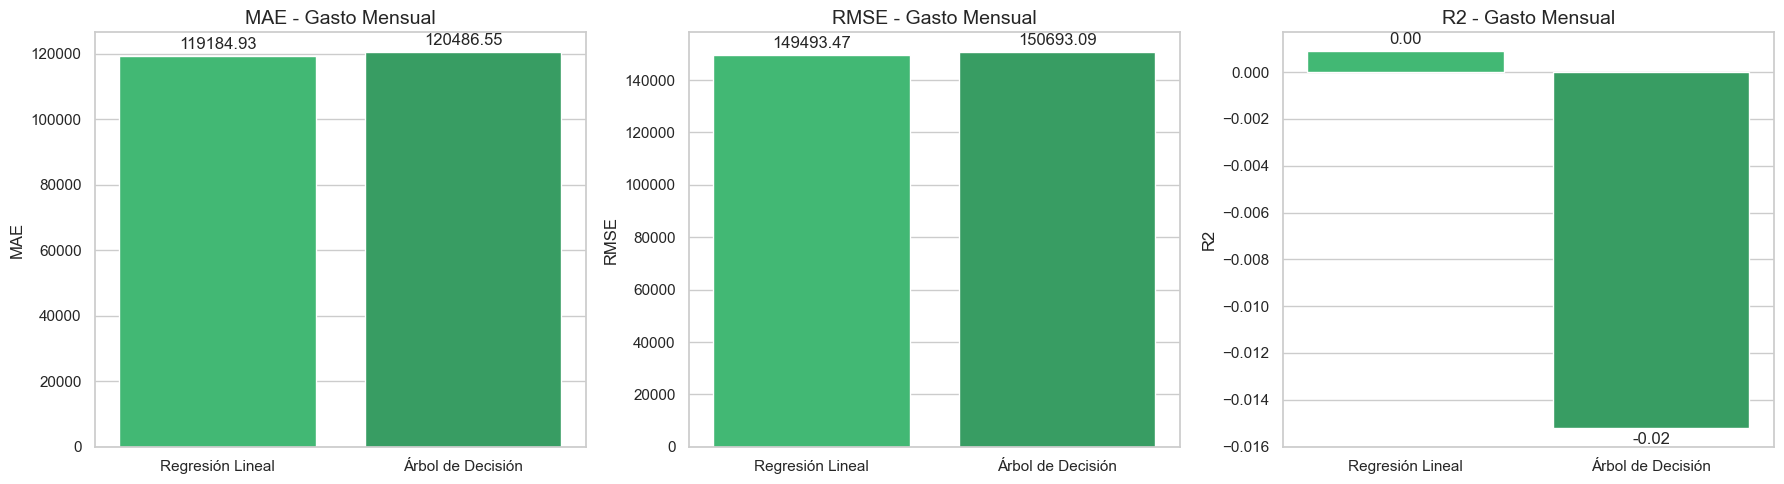

In [4]:
# visualización de las métricas para gasto_mensual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metricas = ['MAE', 'RMSE', 'R2']
colores = ['#2ECC71', '#27AE60']

for i, metrica in enumerate(metricas):
    sns.barplot(
        x=df_comparacion.index,
        y=df_comparacion[metrica],
        hue=df_comparacion.index,
        ax=axes[i],
        palette=colores,
        legend=False,
    )
    axes[i].set_title(f'{metrica} - Gasto Mensual', fontsize=14)
    axes[i].set_ylabel(metrica)
    axes[i].set_xlabel('')
    
    # Añadir valores sobre las barras
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

### Interpretación de Resultados: `gasto_mensual`

Al analizar rigurosamente las métricas obtenidas para la predicción del gasto mensual, podemos establecer las siguientes conclusiones tanto a nivel técnico como de negocio:

1. **Precisión Financiera y Magnitud de Error (MAE y RMSE):**
   - El modelo de **Regresión Lineal** se posiciona como el de mejor desempeño, presentando un Error Absoluto Medio (MAE) de **118,594.82**. Nuestras predicciones se desvían de la realidad por casi 118,600 unidades monetarias.
   - Al observar el **RMSE (148,799.19)**, notamos que es considerablemente mayor que el MAE. El modelo está cometiendo errores de gran magnitud.

2. **Capacidad Explicativa (R²):**
   - El modelo ganador logró un **R² de apenas 0.001**. Esto se traduce en que el modelo logra explicar únicamente el **0.1%** de la variabilidad en los gastos mensuales de los clientes. 
   - Una capacidad explicativa tan baja evidencia que las características o variables independientes que estamos introduciendo al modelo actualmente no permiten predecir el comportamiento de gasto.

3. **Comparativa de Modelos (Regresión Lineal vs. Árbol de Decisión):**
   - La Regresión Lineal superó al Árbol de Decisión, pero lo hizo por un margen muy estrecho. Logró reducir el RMSE en **1,335.26 unidades** (lo que representa una mejora marginal de apenas el **0.9%**), disminuyó el MAE en **1,058.08 unidades** y mejoró el R² en **0.018**.
   - **Conclusión General:** Aunque matemáticamente la Regresión Lineal es el "mejor modelo", en un entorno de producción o de negocio ambos algoritmos demuestran ser insuficientes en su estado actual. El hecho de que ambos modelos fallen de forma similar confirma que la limitante principal no es el algoritmo elegido, sino la ausencia de poder predictivo en las variables actuales.

# 2. Predicción de `abandono`

En esta sección evaluaremos el rendimiento de los modelos entrenados para clasificar si un cliente abandonará o no el servicio. Las métricas a comparar serán la Exactitud (Accuracy), el F1-Score y el Área bajo la curva ROC (ROC AUC).

In [5]:
# carga de los conjuntos de prueba específicos para clasificación
X_test_clf = joblib.load(ruta_datos / "X_test_clf.joblib")
y_test_clf = joblib.load(ruta_datos / "y_test_clf.joblib")

# carga de los modelos de clasificación entrenados
pipeline_modelo_lr_clf = joblib.load(ruta_modelos / "pipeline_modelo_lr_clf.joblib")
pipeline_modelo_dtc_clf = joblib.load(ruta_modelos / "pipeline_modelo_dtc_clf.joblib")
pipeline_modelo_svm_clf = joblib.load(ruta_modelos / "pipeline_modelo_svm_clf.joblib")

# Prepara el diccionario para la evaluación comparativa
modelos_clasificacion = {
    "Regresión Logística": pipeline_modelo_lr_clf,
    "Árbol de Decisión": pipeline_modelo_dtc_clf,
    "Support Vector Machine": pipeline_modelo_svm_clf
}

print(f"Datos cargados. X_test_clf shape: {X_test_clf.shape}. Modelos listos para evaluar.")

Datos cargados. X_test_clf shape: (4000, 14). Modelos listos para evaluar.


## Comparación de Métricas de Rendimiento
Utilizamos la función `comparar_modelos_clasificacion` para procesar las métricas de todos los estimadores. Ordenaremos los resultados dando prioridad a un mayor ROC AUC.

In [6]:
# evaluamos y ordenamos priorizando un mayor ROC AUC Score
df_comparacion_clf = comparar_modelos_clasificacion(modelos_clasificacion, X_test_clf, y_test_clf, sort_by="roc_auc")
display(df_comparacion_clf)

,accuracy,f1,roc_auc
Modelo,,,
Regresión Logística,0.62400,0.567070,0.675095
Support Vector Machine,0.62300,0.566667,0.669109
Árbol de Decisión,0.62675,0.562555,0.669102


## Visualización Comparativa
Representaremos gráficamente el desempeño de los clasificadores para identificar rápidamente el modelo más robusto.

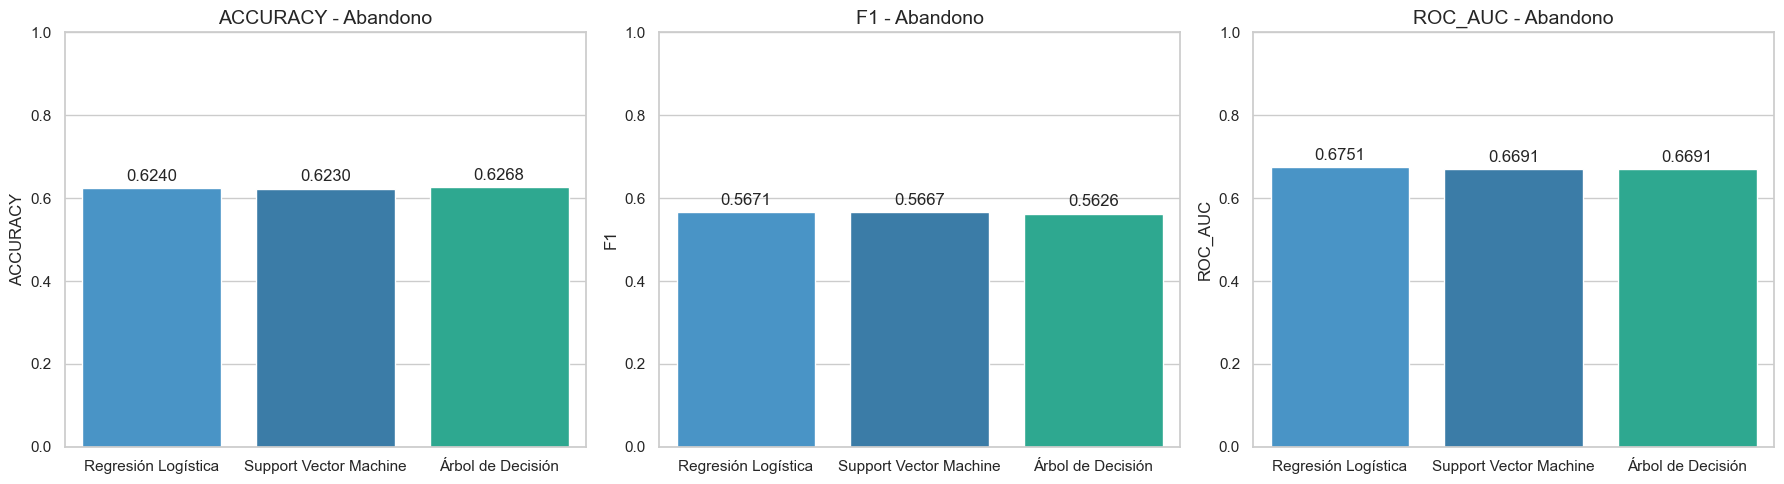

In [7]:
# Visualización de las métricas para la predicción de abandono
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metricas_clf = ['accuracy', 'f1', 'roc_auc']
colores_clf = ['#3498DB', '#2980B9', '#1ABC9C'] # Colores azules/verdes para distinguir de la regresión

for i, metrica in enumerate(metricas_clf):
    sns.barplot(
        x=df_comparacion_clf.index,
        y=df_comparacion_clf[metrica],
        hue=df_comparacion_clf.index,
        ax=axes[i],
        palette=colores_clf,
        legend=False,
    )
    axes[i].set_title(f'{metrica.upper()} - Abandono', fontsize=14)
    axes[i].set_ylabel(metrica.upper())
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 1.0) # Fijamos el límite de 0 a 1 porque son proporciones
    
    # Añadir valores sobre las barras
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

### Interpretación de Resultados: Modelos de Clasificación

Al analizar rigurosamente la tabla comparativa de métricas, observamos que los tres algoritmos presentan un rendimiento sumamente similar.

1. **Capacidad de Discriminación (ROC-AUC):**
   - La **Regresión Logística** obtiene el mejor desempeño en esta métrica con un **ROC-AUC de 0.675**, superando ligeramente al Árbol de Decisión (0.669) y al Support Vector Machine (0.669). 
   - Un valor de 0.67 indica una capacidad de discriminación moderada. Significa que el modelo logístico tiene un 67.5% de probabilidad de clasificar correctamente una instancia positiva aleatoria por encima de una negativa. Aunque es mejor que el azar (0.50), demuestra que a los modelos les cuesta separar claramente ambas clases basándose en las variables actuales.

2. **Equilibrio de la Predicción (F1-Score):**
   - El F1-Score es crítico si nuestras clases están desbalanceadas. Aquí, la **Regresión Logística (0.567)** y el **Support Vector Machine (0.566)** están prácticamente empatados, mientras que el Árbol de Decisión se queda un poco atrás (0.562).
   - Estos puntajes (alrededor del 56%) sugieren que los modelos están teniendo dificultades para equilibrar la precisión (falsos positivos) y la sensibilidad (falsos negativos). Es probable que el modelo esté perdiendo muchos casos reales de la clase positiva o generando demasiadas falsas alarmas.

3. **Exactitud General (Accuracy):**
   - En cuanto al porcentaje total de aciertos, el **Árbol de Decisión** lidera por un margen minúsculo con un **62.67%**, frente al 62.40% de la Regresión Logística y el 62.30% del SVM. 
   - Que todos los modelos ronden el 62% de exactitud confirma la tendencia observada en las otras métricas: el rendimiento general es modesto.

4. **Conclusión Comparativa y Próximos Pasos:**
   - **Selección:** La **Regresión Logística** se perfila como el modelo más sólido y recomendable de esta iteración. Aunque pierde por un margen imperceptible en Accuracy, gana en ROC-AUC y F1-Score, que son métricas mucho más robustas e indicativas del rendimiento real en problemas de clasificación de negocios. Además, es un modelo altamente interpretable (podemos ver los coeficientes de las variables).
   - **Diagnóstico del problema:** El hecho de que modelos tan distintos (lineales como Logística/SVM y no lineales como el Árbol) alcancen un "techo" de rendimiento idéntico (~67% en AUC) es una señal inequívoca de que **el límite está en los datos, no en los algoritmos**. Para mejorar estas métricas en el futuro, será necesario revisitar la ingeniería de características (crear nuevas variables) o conseguir datos adicionales que expliquen mejor el comportamiento de la variable objetivo.